In [7]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from itertools import combinations
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from pyod.models.knn import KNN
from pyod.models.copod import COPOD
import warnings
warnings.filterwarnings('ignore')

dataset_path = 'datasets'
files = sorted([f for f in os.listdir(dataset_path) if f.endswith('.parquet')])

print("Available files:")
for f in files:
    size_mb = os.path.getsize(os.path.join(dataset_path, f)) / 1e6
    print(f"  {f:70s} {size_mb:.1f} MB")

Available files:
  Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet             83.5 MB
  Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet      76.4 MB
  DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet             89.5 MB
  DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet           33.4 MB
  DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet             98.6 MB
  DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet               58.0 MB
  Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet          51.0 MB
  Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet           29.3 MB
  Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet             104.0 MB
  Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet               101.4 MB


In [8]:
df_raw = pd.read_parquet(os.path.join(dataset_path, files[0]))
df_raw.columns = df_raw.columns.str.strip()

print(f"Shape: {df_raw.shape}")
print(f"\nAll columns ({len(df_raw.columns)}):")
for col in df_raw.columns:
    sample = df_raw[col].dropna().iloc[0] if df_raw[col].notna().any() else 'N/A'
    print(f"  '{col}' → dtype={df_raw[col].dtype}, sample={sample}")

Shape: (771587, 78)

All columns (78):
  'Protocol' → dtype=int8, sample=6
  'Flow Duration' → dtype=int32, sample=141385
  'Total Fwd Packets' → dtype=int32, sample=9
  'Total Backward Packets' → dtype=int32, sample=7
  'Fwd Packets Length Total' → dtype=int32, sample=553
  'Bwd Packets Length Total' → dtype=float32, sample=3773.0
  'Fwd Packet Length Max' → dtype=int16, sample=202
  'Fwd Packet Length Min' → dtype=int16, sample=0
  'Fwd Packet Length Mean' → dtype=float32, sample=61.44444274902344
  'Fwd Packet Length Std' → dtype=float32, sample=87.53443908691406
  'Bwd Packet Length Max' → dtype=int16, sample=1460
  'Bwd Packet Length Min' → dtype=int16, sample=0
  'Bwd Packet Length Mean' → dtype=float32, sample=539.0
  'Bwd Packet Length Std' → dtype=float32, sample=655.4329223632812
  'Flow Bytes/s' → dtype=float64, sample=30597.30523
  'Flow Packets/s' → dtype=float64, sample=113.1661775
  'Flow IAT Mean' → dtype=float32, sample=9425.6669921875
  'Flow IAT Std' → dtype=float32,

In [4]:
COLUMN_MAP = {
    'Total Fwd Packets'                 : 'fwd_pkts',
    'Total Backward Packets'            : 'bwd_pkts',
    'Flow Duration'                     : 'flow_duration',
    'Fwd Packets Length Total'          : 'fwd_pkt_size',    
    'Bwd Packets Length Total'          : 'bwd_pkt_size',    
    'Packet Length Std'                 : 'pkt_len_std',     
    'Fwd Packets/s'                     : 'fwd_pkt_rate',    
    'Bwd Packets/s'                     : 'bwd_pkt_rate',    
    'Protocol'                          : 'protocol',        
    'Packet Length Mean'                : 'pkt_len_mean',    
    'Flow Bytes/s'                      : 'flow_bytes_rate', 
    'Label'                             : 'label',
    'Dst Port'                          : 'dst_port',
}

def standardize_columns(df):
    df.columns = df.columns.str.strip()
    rename = {col: COLUMN_MAP[col] for col in df.columns if col in COLUMN_MAP}
    df = df.rename(columns=rename)
    if df.columns.duplicated().any():
        df = df.loc[:, ~df.columns.duplicated()]
    return df


df_check = pd.read_parquet(os.path.join(dataset_path, files[0]))
df_check.columns = df_check.columns.str.strip()
df_check = standardize_columns(df_check)

required = ['fwd_pkts', 'bwd_pkts', 'flow_duration',
            'fwd_pkt_size', 'bwd_pkt_size', 'pkt_len_std', 'label']
found   = [c for c in required if c in df_check.columns]
missing = [c for c in required if c not in df_check.columns]

print(f" Found    : {found}")
print(f" Missing  : {missing}")
print(f"\nAll standardized columns: {list(df_check.columns)}")
print(f"\nSample row:\n{df_check.iloc[0][found].to_string()}")

 Found    : ['fwd_pkts', 'bwd_pkts', 'flow_duration', 'fwd_pkt_size', 'bwd_pkt_size', 'pkt_len_std', 'label']
 Missing  : []

All standardized columns: ['protocol', 'flow_duration', 'fwd_pkts', 'bwd_pkts', 'fwd_pkt_size', 'bwd_pkt_size', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'flow_bytes_rate', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'fwd_pkt_rate', 'bwd_pkt_rate', 'Packet Length Min', 'Packet Length Max', 'pkt_len_mean', 'pkt_len_std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Fl

In [5]:
FEATURE_MAPPING_NOTES = {
    'n_dst_ip'      : 'NOT AVAILABLE (IP columns stripped). Approximated by fwd_pkt_rate.',
    'n_src_ip'      : 'NOT AVAILABLE (IP columns stripped). Approximated by bwd_pkt_rate.',
    'n_dst_ports'   : 'NOT AVAILABLE (port columns stripped). Approximated by protocol diversity proxy.',
    'n_src_ports'   : 'NOT AVAILABLE (port columns stripped). Approximated by flow count proxy.',
    'n_fwd_pkts'    : 'DIRECT: fwd_pkts (Tot Fwd Pkts)',
    'n_bwd_pkts'    : 'DIRECT: bwd_pkts (Tot Bwd Pkts)',
    'sum_flx_dur'   : 'DIRECT: flow_duration (Flow Duration)',
    'tot_flx'       : 'APPROXIMATED: treated as 1 per row (pre-aggregated flows)',
    'sum_pkts_size' : 'DIRECT: fwd_pkt_size + bwd_pkt_size',
    'std_pkt_size'  : 'DIRECT: pkt_len_std (Packet Length Std)',
}

print("Paper Feature → Implementation Mapping:")
for feat, note in FEATURE_MAPPING_NOTES.items():
    status = "✅" if "DIRECT" in note else ("⚠️ " if "APPROX" in note else "❌")
    print(f"  {status} {feat:<15}: {note}")

Paper Feature → Implementation Mapping:
  ❌ n_dst_ip       : NOT AVAILABLE (IP columns stripped). Approximated by fwd_pkt_rate.
  ❌ n_src_ip       : NOT AVAILABLE (IP columns stripped). Approximated by bwd_pkt_rate.
  ❌ n_dst_ports    : NOT AVAILABLE (port columns stripped). Approximated by protocol diversity proxy.
  ❌ n_src_ports    : NOT AVAILABLE (port columns stripped). Approximated by flow count proxy.
  ✅ n_fwd_pkts     : DIRECT: fwd_pkts (Tot Fwd Pkts)
  ✅ n_bwd_pkts     : DIRECT: bwd_pkts (Tot Bwd Pkts)
  ✅ sum_flx_dur    : DIRECT: flow_duration (Flow Duration)
  ⚠️  tot_flx        : APPROXIMATED: treated as 1 per row (pre-aggregated flows)
  ✅ sum_pkts_size  : DIRECT: fwd_pkt_size + bwd_pkt_size
  ✅ std_pkt_size   : DIRECT: pkt_len_std (Packet Length Std)


In [6]:
CHUNK_SIZE = 100

def build_feature_matrix(df, chunk_size=CHUNK_SIZE):
    df = df.copy()
    df['label'] = df['label'].astype(str).str.strip()

    records = []
    n_chunks = len(df) // chunk_size

    if n_chunks == 0:
        print(f"   Too few rows ({len(df)}) for chunk_size={chunk_size}.")
        return pd.DataFrame()

    for i in range(n_chunks):
        chunk = df.iloc[i*chunk_size : (i+1)*chunk_size]

        record = {
            'f1_n_fwd_pkts'   : chunk['fwd_pkts'].sum(),
            'f2_n_bwd_pkts'   : chunk['bwd_pkts'].sum(),
            'f3_sum_flx_dur'  : chunk['flow_duration'].sum(),
            'f4_sum_pkts_size': (chunk['fwd_pkt_size'] +
                                  chunk['bwd_pkt_size']).sum(),
            'f5_std_pkt_size' : chunk['pkt_len_std'].mean(),
            'f6_tot_flx'      : len(chunk),
            'f7_n_dst_ports'  : chunk['dst_port'].nunique() 
                                if 'dst_port' in chunk.columns else 0,
            'f8_proto_div'    : chunk['protocol'].nunique()
                                if 'protocol' in chunk.columns else 0.0,
            'f9_dur_var'      : chunk['flow_duration'].std(),
            'chunk_id'        : i,
            'label'           : int((chunk['label'].str.lower() != 'benign').any()),
            'attack_types'    : ','.join(chunk['label'].unique()),
        }
        records.append(record)

    agg_df = pd.DataFrame(records)
    print(f"  Chunks: {len(agg_df):,}  |  Attack rate: {agg_df['label'].mean()*100:.2f}%")
    return agg_df


FEATURE_COLS = [
    'f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur',
    'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_tot_flx',
    'f7_n_dst_ports', 'f8_proto_div', 'f9_dur_var'
]


SRC_FEATURE_COLS = [
    'f1_n_fwd_pkts',    
    'f7_n_dst_ports',  
    'f8_proto_div',     
    'f9_dur_var',       
    'f4_sum_pkts_size', 
]

DST_FEATURE_COLS = [
    'f2_n_bwd_pkts',    
    'f3_sum_flx_dur',   
    'f5_std_pkt_size',  
    'f6_tot_flx',       
    'f4_sum_pkts_size', 
]
SRC_PAIRS = list(combinations(SRC_FEATURE_COLS, 2))  
DST_PAIRS = list(combinations(DST_FEATURE_COLS, 2))  
print(f" All features       : {len(FEATURE_COLS)} → {len(FEATURE_COLS)*(len(FEATURE_COLS)-1)//2} pairs")
print(f" Src feature subset : {len(SRC_FEATURE_COLS)} features → {len(SRC_PAIRS)} pairs")
print(f" Dst feature subset : {len(DST_FEATURE_COLS)} features → {len(DST_PAIRS)} pairs")

 All features       : 9 → 36 pairs
 Src feature subset : 5 features → 10 pairs
 Dst feature subset : 5 features → 10 pairs


In [7]:
def build_feature_matrix_balanced(df, chunk_size=CHUNK_SIZE, max_attack_rate=0.05):
    """Same as build_feature_matrix, but caps attack rate at file level."""
    df = df.copy()
    df['label'] = df['label'].astype(str).str.strip()
    df['is_attack'] = (df['label'].str.lower() != 'benign').astype(int)
    n_benign = (df['is_attack'] == 0).sum()
    n_attack = (df['is_attack'] == 1).sum()
    current_rate = n_attack / max(len(df), 1)
    if current_rate > max_attack_rate and n_benign > 0:
        target_attack = int(n_benign * max_attack_rate / (1 - max_attack_rate))
        attack_rows = df[df['is_attack'] == 1].sample(
            n=min(target_attack, n_attack), random_state=42)
        df = pd.concat([df[df['is_attack'] == 0], attack_rows]).sort_index()
        print(f"    Rebalanced: kept {len(df)} flows "
              f"(attack={df['is_attack'].mean()*100:.1f}%)")
    df = df.drop(columns=['is_attack'])
    return build_feature_matrix(df, chunk_size)
def safe_clean(df):
    for col in df.columns:
        if hasattr(df[col], 'cat'):
            df[col] = df[col].astype(str)
        elif pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace([np.inf, -np.inf], np.nan).fillna(0)
    return df
all_aggs = []
print("Processing all parquet files\n")
for fname in files:
    fpath = os.path.join(dataset_path, fname)
    print(f"{'='*55}")
    print(f"File: {fname}")
    df = pd.read_parquet(fpath)
    df.columns = df.columns.str.strip()
    df = standardize_columns(df)
    df = safe_clean(df)
    required = ['fwd_pkts', 'bwd_pkts', 'flow_duration',
                'fwd_pkt_size', 'bwd_pkt_size', 'pkt_len_std', 'label']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f"  Skipping — missing: {missing}")
        continue
    print(f"  Flows : {len(df):,}")
    agg = build_feature_matrix_balanced(df) 
    if agg.empty:
        continue
    agg['source_file'] = fname
    all_aggs.append(agg)
all_aggregates = pd.concat(all_aggs, ignore_index=True)

src_aggregates = all_aggregates.copy()
dst_aggregates = all_aggregates.copy()

print(f" all_aggregates : {all_aggregates.shape}")
print(f" src = dst      : same rows, different feature subsets for scoring")
print(f" Attack rate    : {all_aggregates['label'].mean()*100:.2f}%")

src_aggregates.to_parquet('/kaggle/working/src_aggregates.parquet', index=False)
dst_aggregates.to_parquet('/kaggle/working/dst_aggregates.parquet', index=False)
feat_config = {
    'all': FEATURE_COLS,
    'src': SRC_FEATURE_COLS,
    'dst': DST_FEATURE_COLS
}
with open('/kaggle/working/feature_cols.json', 'w') as f:
    json.dump(feat_config, f)
print("Saved.")

Processing all parquet files

File: Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 771,587
    Rebalanced: kept 660054 flows (attack=5.0%)
  Chunks: 6,600  |  Attack rate: 6.65%
File: Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 619,346
    Rebalanced: kept 552889 flows (attack=5.0%)
  Chunks: 5,528  |  Attack rate: 5.30%
File: DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 954,846
    Rebalanced: kept 399454 flows (attack=5.0%)
  Chunks: 3,994  |  Attack rate: 5.38%
File: DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 561,396
    Rebalanced: kept 379794 flows (attack=5.0%)
  Chunks: 3,797  |  Attack rate: 18.09%
File: DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 794,812
    Rebalanced: kept 782629 flows (attack=5.0%)
  Chunks: 7,826  |  Attack rate: 5.19%
File: DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
  Flows : 591,873
    Rebalanced: kept 470125 f

In [8]:
src_aggregates.to_parquet('/kaggle/working/src_aggregates.parquet', index=False)
dst_aggregates.to_parquet('/kaggle/working/dst_aggregates.parquet', index=False)

with open('/kaggle/working/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print("MODULE 1 COMPLETE — Summary")
print(f"src_aggregates : {src_aggregates.shape}")
print(f"dst_aggregates : {dst_aggregates.shape}")
print(f"Feature cols   : {FEATURE_COLS}")
print(f"Label encoding : 0=benign, 1=attack")

MODULE 1 COMPLETE — Summary
src_aggregates : (55225, 13)
dst_aggregates : (55225, 13)
Feature cols   : ['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_tot_flx', 'f7_n_dst_ports', 'f8_proto_div', 'f9_dur_var']
Label encoding : 0=benign, 1=attack


In [9]:
src_aggregates = pd.read_parquet('/kaggle/working/src_aggregates.parquet')
dst_aggregates = pd.read_parquet('/kaggle/working/dst_aggregates.parquet')
with open('/kaggle/working/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)
FEATURE_PAIRS = list(combinations(FEATURE_COLS, 2))
N_PAIRS       = len(FEATURE_PAIRS)
print(f"src_aggregates : {src_aggregates.shape}")
print(f"dst_aggregates : {dst_aggregates.shape}")
print(f"Feature cols   : {FEATURE_COLS}")
print(f"Feature pairs  : {N_PAIRS}")

src_aggregates : (55225, 13)
dst_aggregates : (55225, 13)
Feature cols   : ['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_tot_flx', 'f7_n_dst_ports', 'f8_proto_div', 'f9_dur_var']
Feature pairs  : 36


In [10]:
CONTAMINATION = 0.05
WINDOW_SIZE   = 2000

def score_windowed(df, feature_cols, feature_pairs, learner_name,window_size=WINDOW_SIZE):

    X_raw   = df[feature_cols].values.astype(np.float64)
    X_raw   = np.where(np.isfinite(X_raw), X_raw, 0.0)
    n_total = len(X_raw)
    scores  = np.zeros(n_total, dtype=np.float32)
    n_pairs = len(feature_pairs)

    for start in range(0, n_total, window_size):
        end   = min(start + window_size, n_total)
        X_win = X_raw[start:end]
        if len(X_win) < 5:
            continue

        scaler = StandardScaler()
        X_sc   = scaler.fit_transform(X_win).astype(np.float32)
        X_sc   = np.nan_to_num(X_sc, nan=0.0, posinf=0.0, neginf=0.0)

        n = X_sc.shape[0]
        flag_counts = np.zeros(n, dtype=np.float32)

        for (fa, fb) in feature_pairs:
            ia = feature_cols.index(fa)
            ib = feature_cols.index(fb)
            X2d = X_sc[:, [ia, ib]]
            if np.std(X2d[:, 0]) < 1e-9 and np.std(X2d[:, 1]) < 1e-9:
                continue
            try:
                if learner_name == 'LOF':
                    clf = LocalOutlierFactor(n_neighbors=min(3, n-1),
                                             contamination=CONTAMINATION,
                                             novelty=False)
                    flags = (clf.fit_predict(X2d) == -1).astype(np.float32)
                elif learner_name == 'OCSVM':
                    clf = OneClassSVM(nu=CONTAMINATION, kernel='rbf',
                                      max_iter=300)
                    clf.fit(X2d)
                    flags = (clf.predict(X2d) == -1).astype(np.float32)
                elif learner_name == 'KNN':
                    clf = KNN(n_neighbors=min(3, n-1),
                              contamination=CONTAMINATION)
                    clf.fit(X2d)
                    flags = clf.labels_.astype(np.float32)
                elif learner_name == 'COPOD':
                    clf = COPOD(contamination=CONTAMINATION)
                    clf.fit(X2d)
                    flags = clf.labels_.astype(np.float32)
                flag_counts += flags
            except Exception:
                continue

        scores[start:end] = flag_counts / max(n_pairs, 1)
    return scores

print(f"Scoring engine ready  |  contamination={CONTAMINATION}"
      f"  |  window={WINDOW_SIZE}")
print(f"Src pairs: {len(SRC_PAIRS)}  |  Dst pairs: {len(DST_PAIRS)}")


Scoring engine ready  |  contamination=0.05  |  window=2000
Src pairs: 10  |  Dst pairs: 10


In [11]:
import time
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
print(f"Scoring {len(src_aggregates):,} source aggregates with windowed approach...")
print(f"Window size={WINDOW_SIZE} rows per window\n")
t0 = time.time()
src_scores_v2 = {}
for learner in SRC_LEARNERS:
    print(f"  [{learner}] ", end='', flush=True)
    t1 = time.time()
    src_scores_v2[learner] = score_windowed(src_aggregates, SRC_FEATURE_COLS, SRC_PAIRS, learner)
    pct = (src_scores_v2[learner] > 0).mean() * 100
    print(f"done ({time.time()-t1:.0f}s)  mean={src_scores_v2[learner].mean():.4f}  flagged={pct:.1f}%")
src_scored_v2 = src_aggregates.copy()
for learner in SRC_LEARNERS:
    src_scored_v2[f'score_{learner}'] = src_scores_v2[learner]
src_scored_v2['ensemble_flag'] = (
    src_scored_v2[[f'score_{l}' for l in SRC_LEARNERS]] > 0
).any(axis=1).astype(int)
tp = (src_scored_v2.loc[src_scored_v2['label']==1, 'ensemble_flag']==1).mean()
fp = (src_scored_v2.loc[src_scored_v2['label']==0, 'ensemble_flag']==1).mean()
print(f"\nTotal elapsed : {time.time()-t0:.0f}s")
print(f"Src Ensemble  TPR={tp:.4f}  FPR={fp:.4f}")
print(f"Paper target  TPR=0.9878        FPR=0.6764")
print(f"v1 result     TPR=0.8719        FPR=0.6224")

Scoring 55,225 source aggregates with windowed approach...
Window size=2000 rows per window

  [LOF] done (2s)  mean=0.0429  flagged=30.1%
  [OCSVM] done (6s)  mean=0.1192  flagged=71.6%
  [COPOD] done (2s)  mean=0.0458  flagged=12.3%

Total elapsed : 10s
Src Ensemble  TPR=0.8198  FPR=0.8108
Paper target  TPR=0.9878        FPR=0.6764
v1 result     TPR=0.8719        FPR=0.6224


In [12]:
DST_LEARNERS = ['LOF', 'KNN', 'COPOD']
print(f"Scoring {len(dst_aggregates):,} destination aggregates with windowed approach...")
print(f"Window size={WINDOW_SIZE}\n")
t0 = time.time()
dst_scores_v2 = {}
for learner in DST_LEARNERS:
    print(f"  [{learner}] ", end='', flush=True)
    t1 = time.time()
    dst_scores_v2[learner] = score_windowed(dst_aggregates, DST_FEATURE_COLS, DST_PAIRS, learner)
    pct = (dst_scores_v2[learner] > 0).mean() * 100
    print(f"done ({time.time()-t1:.0f}s)  mean={dst_scores_v2[learner].mean():.4f}  flagged={pct:.1f}%")
dst_scored_v2 = dst_aggregates.copy()
for learner in DST_LEARNERS:
    dst_scored_v2[f'score_{learner}'] = dst_scores_v2[learner]
dst_scored_v2['ensemble_flag'] = (
    dst_scored_v2[[f'score_{l}' for l in DST_LEARNERS]] > 0
).any(axis=1).astype(int)
tp = (dst_scored_v2.loc[dst_scored_v2['label']==1, 'ensemble_flag']==1).mean()
fp = (dst_scored_v2.loc[dst_scored_v2['label']==0, 'ensemble_flag']==1).mean()

assert len(src_scored_v2) == len(dst_scored_v2), "Row count mismatch!"
assert (src_scored_v2['label'].values == dst_scored_v2['label'].values).all(), \
    "Label mismatch!"
print("Pairing verified: src and dst have identical rows and labels")

print(f"\nTotal elapsed : {time.time()-t0:.0f}s")
print(f"Dst Ensemble  TPR={tp:.4f}  FPR={fp:.4f}")
print(f"Paper target  TPR=0.9384        FPR=0.3994")
print(f"v1 result     TPR=0.7092        FPR=0.7730")

Scoring 55,225 destination aggregates with windowed approach...
Window size=2000

  [LOF] done (2s)  mean=0.0490  flagged=35.2%
  [KNN] done (2s)  mean=0.0497  flagged=14.6%
  [COPOD] done (1s)  mean=0.0500  flagged=12.4%
Pairing verified: src and dst have identical rows and labels

Total elapsed : 4s
Dst Ensemble  TPR=0.4900  FPR=0.4409
Paper target  TPR=0.9384        FPR=0.3994
v1 result     TPR=0.7092        FPR=0.7730


In [13]:
src_scored_v2.to_parquet('/kaggle/working/src_scored.parquet', index=False)
dst_scored_v2.to_parquet('/kaggle/working/dst_scored.parquet', index=False)
print("Saved src_scored.parquet and dst_scored.parquet (v2)")

Saved src_scored.parquet and dst_scored.parquet (v2)


Saved: src_scored.parquet  dst_scored.parquet


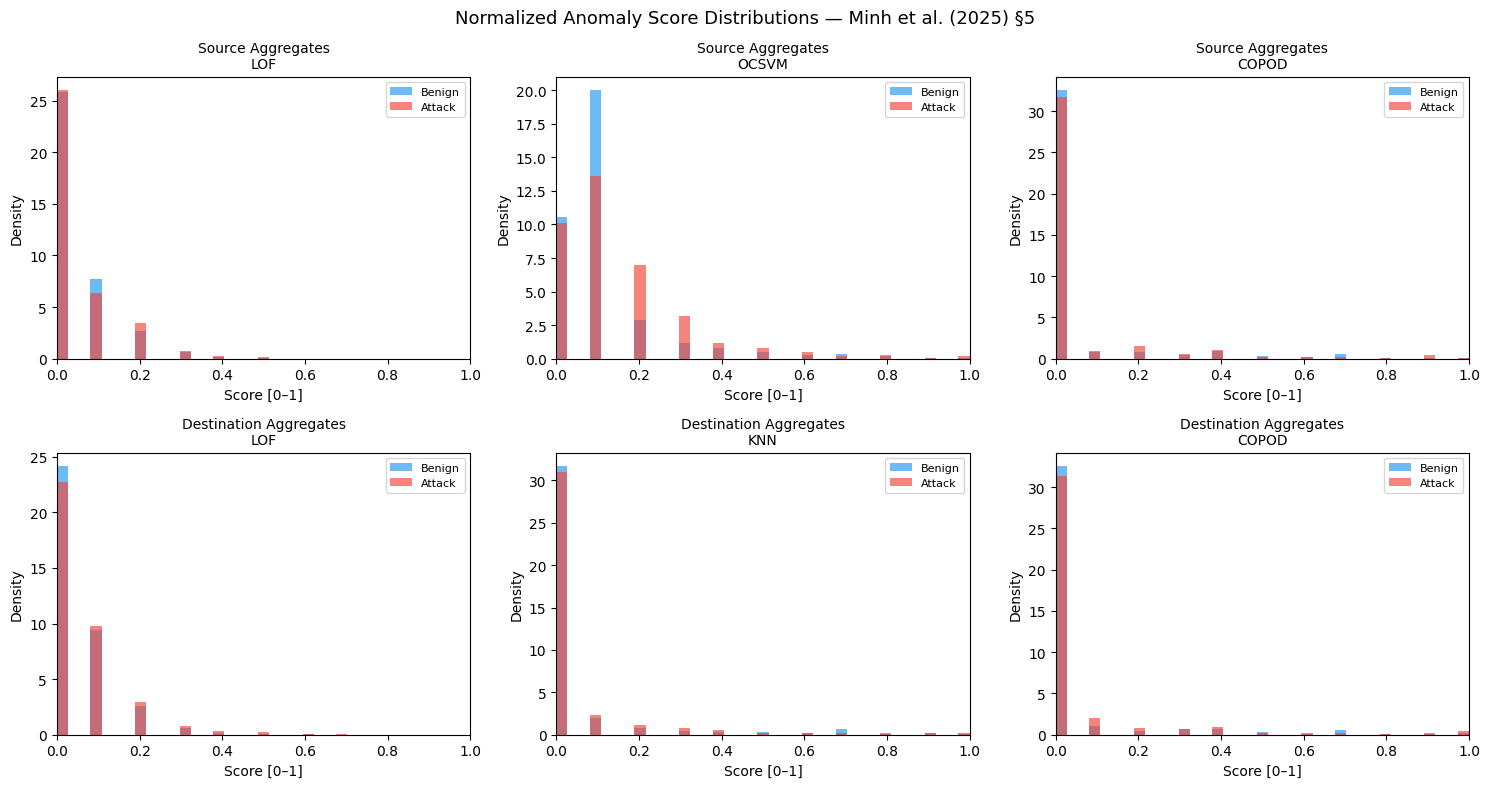


Individual + Ensemble Performance (compare with paper Table 3 & 8):
Perspective       Learner    TPR    FPR
        Src           LOF 0.2965 0.3014
        Src         OCSVM 0.7272 0.7149
        Src         COPOD 0.1416 0.1198
        Dst           LOF 0.3868 0.3469
        Dst           KNN 0.1621 0.1433
        Dst         COPOD 0.1540 0.1199
        Src Ensemble (OR) 0.8198 0.8108
        Dst Ensemble (OR) 0.4900 0.4409


In [14]:
src_scored = src_scored_v2
dst_scored = dst_scored_v2
src_scored.to_parquet('/kaggle/working/src_scored.parquet', index=False)
dst_scored.to_parquet('/kaggle/working/dst_scored.parquet', index=False)
print("Saved: src_scored.parquet  dst_scored.parquet")
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Normalized Anomaly Score Distributions — Minh et al. (2025) §5', fontsize=13)
COLORS = {0: '#2196F3', 1: '#F44336'}
NAMES  = {0: 'Benign',  1: 'Attack'}
for row_idx, (scored_df, title, learners) in enumerate([
    (src_scored, 'Source Aggregates',      SRC_LEARNERS),
    (dst_scored, 'Destination Aggregates', DST_LEARNERS),
]):
    for col_idx, learner in enumerate(learners):
        ax  = axes[row_idx][col_idx]
        col = f'score_{learner}'
        for lbl in [0, 1]:
            data = scored_df.loc[scored_df['label'] == lbl, col]
            ax.hist(data, bins=37, alpha=0.65, color=COLORS[lbl],
                    label=NAMES[lbl], density=True, range=(0, 1))
        ax.set_title(f'{title}\n{learner}', fontsize=10)
        ax.set_xlabel('Score [0–1]')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('/kaggle/working/module2_score_distributions.png', dpi=120)
plt.show()

rows = []
for learner in SRC_LEARNERS:
    col = f'score_{learner}'
    tpr = (src_scored.loc[src_scored['label']==1, col] > 0).mean()
    fpr = (src_scored.loc[src_scored['label']==0, col] > 0).mean()
    rows.append({'Perspective': 'Src', 'Learner': learner,
                 'TPR': round(tpr, 4), 'FPR': round(fpr, 4)})
for learner in DST_LEARNERS:
    col = f'score_{learner}'
    tpr = (dst_scored.loc[dst_scored['label']==1, col] > 0).mean()
    fpr = (dst_scored.loc[dst_scored['label']==0, col] > 0).mean()
    rows.append({'Perspective': 'Dst', 'Learner': learner,
                 'TPR': round(tpr, 4), 'FPR': round(fpr, 4)})

tp_src = (src_scored.loc[src_scored['label']==1, 'ensemble_flag']==1).mean()
fp_src = (src_scored.loc[src_scored['label']==0, 'ensemble_flag']==1).mean()
tp_dst = (dst_scored.loc[dst_scored['label']==1, 'ensemble_flag']==1).mean()
fp_dst = (dst_scored.loc[dst_scored['label']==0, 'ensemble_flag']==1).mean()
rows.append({'Perspective':'Src','Learner':'Ensemble (OR)','TPR':round(tp_src,4),'FPR':round(fp_src,4)})
rows.append({'Perspective':'Dst','Learner':'Ensemble (OR)','TPR':round(tp_dst,4),'FPR':round(fp_dst,4)})
perf_df = pd.DataFrame(rows)
print("\nIndividual + Ensemble Performance (compare with paper Table 3 & 8):")
print(perf_df.to_string(index=False))


In [15]:
src_scored = pd.read_parquet('/kaggle/working/src_scored.parquet')
dst_scored = pd.read_parquet('/kaggle/working/dst_scored.parquet')
with open('/kaggle/working/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']
print(f"src_scored : {src_scored.shape}")
print(f"dst_scored : {dst_scored.shape}")
print(src_scored.columns.tolist())

src_scored : (55225, 17)
dst_scored : (55225, 17)
['f1_n_fwd_pkts', 'f2_n_bwd_pkts', 'f3_sum_flx_dur', 'f4_sum_pkts_size', 'f5_std_pkt_size', 'f6_tot_flx', 'f7_n_dst_ports', 'f8_proto_div', 'f9_dur_var', 'chunk_id', 'label', 'attack_types', 'source_file', 'score_LOF', 'score_OCSVM', 'score_COPOD', 'ensemble_flag']


In [16]:
N_ROWS      = 15    
N_INTERVALS = 15    
N_CHANNELS  = 3     

def make_image(chunk, learners, n_rows=N_ROWS, n_cols=N_INTERVALS):

    img = np.zeros((n_rows, n_cols, N_CHANNELS), dtype=np.float32)

    chunk_list = list(chunk.iterrows())

    for agg_idx, (_, row) in enumerate(chunk_list):
        if agg_idx >= n_rows:
            break
        for c, learner in enumerate(learners):
            score = float(row.get(f'score_{learner}', 0.0))
            img[agg_idx, :, c] = score

    return img


def build_heatmap_pair(src_chunk, dst_chunk, src_learners, dst_learners):
    src_img = make_image(src_chunk, src_learners)
    dst_img = make_image(dst_chunk, dst_learners)
    return src_img, dst_img


print(f"Image shape per pair: ({N_ROWS}, {N_INTERVALS}, {N_CHANNELS})")
print(f"Non-zero potential  : up to {N_ROWS * N_INTERVALS} pixels per channel")
print(f"CNN input note      : will upscale to (451, 15, 3) via tf.image.resize")

Image shape per pair: (15, 15, 3)
Non-zero potential  : up to 225 pixels per channel
CNN input note      : will upscale to (451, 15, 3) via tf.image.resize


In [17]:
SRC_LEARNERS = ['LOF', 'OCSVM', 'COPOD']
DST_LEARNERS = ['LOF', 'KNN',   'COPOD']

n_windows = min(len(src_scored), len(dst_scored)) // N_INTERVALS
print(f"Building {n_windows} image pairs  |  shape per pair: ({N_ROWS},{N_INTERVALS},3)\n")

src_images, dst_images, labels = [], [], []

for w in range(n_windows):
    s = w * N_INTERVALS
    e = s + N_INTERVALS
    src_chunk = src_scored.iloc[s:e]
    dst_chunk  = dst_scored.iloc[s:e]

    src_img, dst_img = build_heatmap_pair(
        src_chunk, dst_chunk, SRC_LEARNERS, DST_LEARNERS)

    lbl = int(src_chunk['label'].any() or dst_chunk['label'].any())
    src_images.append(src_img)
    dst_images.append(dst_img)
    labels.append(lbl)

X_src    = np.stack(src_images).astype(np.float32)
X_dst    = np.stack(dst_images).astype(np.float32)
y_labels = np.array(labels)

print(f"X_src    : {X_src.shape}")
print(f"X_dst    : {X_dst.shape}")
print(f"y_labels : {y_labels.shape}  attack={y_labels.mean()*100:.2f}%")

Building 3681 image pairs  |  shape per pair: (15,15,3)

X_src    : (3681, 15, 15, 3)
X_dst    : (3681, 15, 15, 3)
y_labels : (3681,)  attack=20.29%


In [19]:
np.save('/kaggle/working/X_src.npy',    X_src)
np.save('/kaggle/working/X_dst.npy',    X_dst)
np.save('/kaggle/working/y_labels.npy', y_labels)
print(f"Saved. Shapes: X_src={X_src.shape}  X_dst={X_dst.shape}  y={y_labels.shape}")

Saved. Shapes: X_src=(3681, 15, 15, 3)  X_dst=(3681, 15, 15, 3)  y=(3681,)


Saved: X_src.npy  X_dst.npy  y_labels.npy


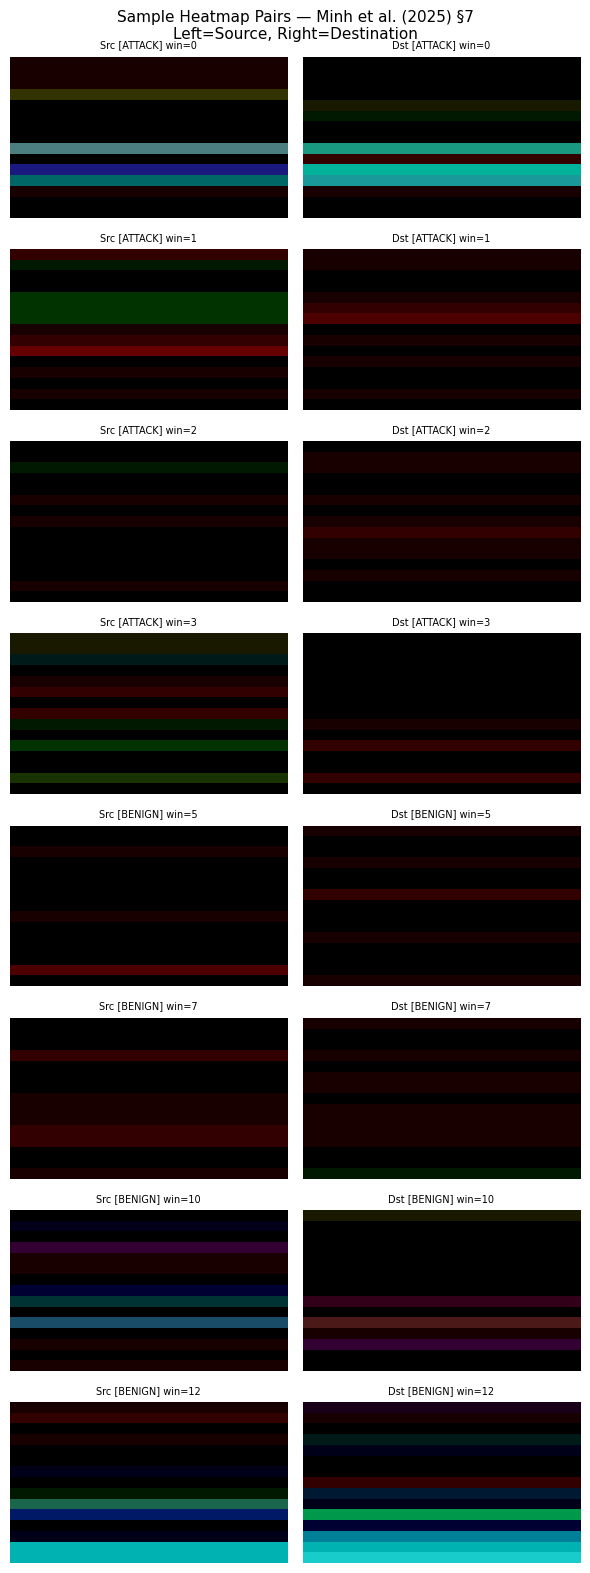

Sample visualization saved.
  Input : image pairs  X_src (3681, 15, 15, 3)  X_dst (3681, 15, 15, 3)
  Labels: y_labels (3681,)  attack_rate=20.29%


In [20]:
print("Saved: X_src.npy  X_dst.npy  y_labels.npy")
attack_idx = np.where(y_labels == 1)[0][:4]
benign_idx = np.where(y_labels == 0)[0][:4]
sample_idx = list(attack_idx) + list(benign_idx)
fig, axes = plt.subplots(len(sample_idx), 2,
                         figsize=(6, len(sample_idx) * 2))
fig.suptitle('Sample Heatmap Pairs — Minh et al. (2025) §7\n'
             'Left=Source, Right=Destination', fontsize=11)
for row, idx in enumerate(sample_idx):
    lbl = "ATTACK" if y_labels[idx] else "BENIGN"
    axes[row][0].imshow(X_src[idx], aspect='auto', interpolation='nearest')
    axes[row][0].set_title(f"Src [{lbl}] win={idx}", fontsize=7)
    axes[row][0].axis('off')
    axes[row][1].imshow(X_dst[idx], aspect='auto', interpolation='nearest')
    axes[row][1].set_title(f"Dst [{lbl}] win={idx}", fontsize=7)
    axes[row][1].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/module3_sample_heatmaps.png', dpi=100)
plt.show()
print("Sample visualization saved.")
print(f"  Input : image pairs  X_src {X_src.shape}  X_dst {X_dst.shape}")
print(f"  Labels: y_labels {y_labels.shape}  attack_rate={y_labels.mean()*100:.2f}%")

In [21]:
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
# Reload
X_src    = np.load('/kaggle/working/X_src.npy')
X_dst    = np.load('/kaggle/working/X_dst.npy')
y_labels = np.load('/kaggle/working/y_labels.npy')

X_src = X_src.astype(np.float32) / 255.0
X_dst = X_dst.astype(np.float32) / 255.0
print(f"X_src  : {X_src.shape}  dtype={X_src.dtype}")
print(f"X_dst  : {X_dst.shape}  dtype={X_dst.dtype}")
print(f"y      : {y_labels.shape}  attack_rate={y_labels.mean()*100:.2f}%")

np.random.seed(42)
idx = np.random.permutation(len(y_labels))
X_src    = X_src[idx]
X_dst    = X_dst[idx]
y_labels = y_labels[idx]
n       = len(y_labels)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)
X_src_train, X_src_val, X_src_test = X_src[:n_train], X_src[n_train:n_train+n_val], X_src[n_train+n_val:]
X_dst_train, X_dst_val, X_dst_test = X_dst[:n_train], X_dst[n_train:n_train+n_val], X_dst[n_train+n_val:]
y_train, y_val, y_test             = y_labels[:n_train], y_labels[n_train:n_train+n_val], y_labels[n_train+n_val:]
print(f"\nTrain : {len(y_train)}  attack={y_train.mean()*100:.1f}%")
print(f"Val   : {len(y_val)}   attack={y_val.mean()*100:.1f}%")
print(f"Test  : {len(y_test)}   attack={y_test.mean()*100:.1f}%")

2026-04-30 21:15:49.422136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777583749.610020      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777583749.663909      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777583750.087458      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777583750.087491      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777583750.087494      57 computation_placer.cc:177] computation placer alr

X_src  : (3681, 15, 15, 3)  dtype=float32
X_dst  : (3681, 15, 15, 3)  dtype=float32
y      : (3681,)  attack_rate=20.29%

Train : 2944  attack=20.9%
Val   : 368   attack=16.8%
Test  : 369   attack=19.2%


In [27]:
import keras_tuner as kt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

def build_tunable_model(hp):
    src_input = tf.keras.Input(shape=(15, 15, 3), name='src_input')
    dst_input = tf.keras.Input(shape=(15, 15, 3), name='dst_input')

    def tunable_branch(inp, prefix):
        x = inp
        # Cap at 2 conv layers — (15→7→3) is safe; 3 layers would give (1,1)
        n_conv = hp.Int(f'{prefix}_n_conv', min_value=1, max_value=2, step=1)
        for i in range(n_conv):
            filters = hp.Int(f'{prefix}_filters_{i}', 32, 128, step=32)
            x = tf.keras.layers.Conv2D(
                filters, (3, 3),
                activation='relu',
                padding='same')(x)
            # Use strides instead of MaxPooling to avoid spatial collapse
            x = tf.keras.layers.Conv2D(
                filters, (3, 3),
                activation='relu',
                padding='same',
                strides=(2, 2))(x)
        # GlobalAveragePooling works regardless of spatial dimensions
        return tf.keras.layers.GlobalAveragePooling2D()(x)

    src_feat = tunable_branch(src_input, 'src')
    dst_feat = tunable_branch(dst_input, 'dst')
    merged   = tf.keras.layers.Concatenate()([src_feat, dst_feat])

    dense_units = hp.Int('dense_units', 64, 256, step=64)
    x = tf.keras.layers.Dense(dense_units, activation='relu')(merged)
    dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
    x = tf.keras.layers.Dropout(dropout)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(
        inputs=[src_input, dst_input],
        outputs=output,
        name='NIDS_CNN_Tuned')

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


# ── Quick shape test BEFORE tuner search ────────────────────
test_model = build_tunable_model(kt.HyperParameters())
test_out = test_model([
    np.zeros((2, 15, 15, 3), dtype=np.float32),
    np.zeros((2, 15, 15, 3), dtype=np.float32)
])
print(f"✅ Shape test passed. Output shape: {test_out.shape}")
test_model.summary()
del test_model

✅ Shape test passed. Output shape: (2, 1)


Model: "NIDS_CNN_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ src_input           │ (None, 15, 15, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dst_input           │ (None, 15, 15, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 15, 15,    │        896 │ src_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 15, 15,    │        896 │ dst_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8, 32)  │      9,248 │ conv2d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_9[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_11[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      4,160 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,513 (95.75 KB)

 Trainable params: 24,513 (95.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
tuner = kt.RandomSearch(
    build_tunable_model,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=15,
    directory='/kaggle/working/kt_search',
    project_name='nids_cnn_v2',   # new project name avoids stale cache
    overwrite=True
)

cw = compute_class_weight('balanced',
                           classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}
print(f"Class weights → benign: {cw[0]:.3f}  attack: {cw[1]:.3f}")

tuner.search(
    [X_src_train, X_dst_train], y_train,
    validation_data=([X_src_val, X_dst_val], y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=5, mode='max')],
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters:")
for k, v in best_hps.values.items():
    print(f"  {k}: {v}")

model = tuner.get_best_models(1)[0]
model.summary()

Trial 15 Complete [00h 00m 14s]
val_auc: 0.5

Best val_auc So Far: 0.5
Total elapsed time: 00h 03m 17s

Best hyperparameters:
  src_n_conv: 1
  src_filters_0: 64
  dst_n_conv: 2
  dst_filters_0: 32
  dense_units: 256
  dropout: 0.2
  learning_rate: 0.0001
  dst_filters_1: 32


Model: "NIDS_CNN_Tuned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dst_input           │ (None, 15, 15, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 15, 15,    │        896 │ dst_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ src_input           │ (None, 15, 15, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 32)  │      9,248 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 15, 15,    │      1,792 │ src_input[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 32)  │      9,248 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 4, 4, 32)  │      9,248 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_5[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     24,832 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        257 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 92,449 (361.13 KB)

 Trainable params: 92,449 (361.13 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
cw = compute_class_weight('balanced',
                           classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=8,
        restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5,
        patience=4, min_lr=1e-6, mode='max'),
    tf.keras.callbacks.ModelCheckpoint(
        '/kaggle/working/best_cnn.keras',
        monitor='val_auc', save_best_only=True, mode='max')
]

history = model.fit(
    [X_src_train, X_dst_train], y_train,
    validation_data=([X_src_val, X_dst_val], y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining complete.")

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6079 - auc: 0.5000 - loss: 0.6923 - precision: 0.1854 - recall: 0.2894 - val_accuracy: 0.8315 - val_auc: 0.5000 - val_loss: 0.6927 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6998 - auc: 0.5000 - loss: 0.6933 - precision: 0.2019 - recall: 0.1244 - val_accuracy: 0.1685 - val_auc: 0.5000 - val_loss: 0.6933 - val_precision: 0.1685 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5266 - auc: 0.5000 - loss: 0.6936 - precision: 0.2115 - recall: 0.4702 - val_accuracy: 0.8315 - val_auc: 0.5000 - val_loss: 0.6928 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5665 - auc: 0.5000 - loss: 0.6915 - precision: 0.1695 - recall: 0.3498 - val_accuracy: 0.1685 - val_auc: 0.5000 - v

CNN Test Set Results  (compare with paper Table 9)
  TP=0  FP=0  FN=71  TN=298
  TPR (Recall) : 0.0000   [paper Combined: 0.9898]
  FPR          : 0.0000   [paper Combined: 0.0093]
  Precision    : 0.0000
  F1-score     : 0.0000   [paper Combined: 0.9906]
  AUC-ROC      : 0.5647

              precision    recall  f1-score   support

      Benign       0.81      1.00      0.89       298
      Attack       0.00      0.00      0.00        71

    accuracy                           0.81       369
   macro avg       0.40      0.50      0.45       369
weighted avg       0.65      0.81      0.72       369



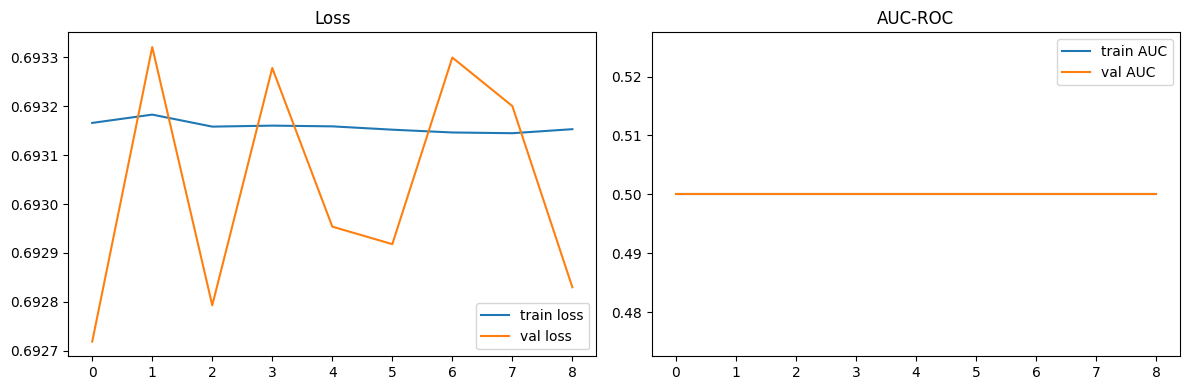

In [30]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score)

model = tf.keras.models.load_model('/kaggle/working/best_cnn.keras')

y_prob = model.predict([X_src_test, X_dst_test], verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
tpr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1   = 2 * prec * tpr / (prec + tpr) if (prec + tpr) > 0 else 0.0
auc  = roc_auc_score(y_test, y_prob)
print("=" * 55)
print("CNN Test Set Results  (compare with paper Table 9)")
print("=" * 55)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"  TPR (Recall) : {tpr:.4f}   [paper Combined: 0.9898]")
print(f"  FPR          : {fpr:.4f}   [paper Combined: 0.0093]")
print(f"  Precision    : {prec:.4f}")
print(f"  F1-score     : {f1:.4f}   [paper Combined: 0.9906]")
print(f"  AUC-ROC      : {auc:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Attack']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='train loss')
axes[0].plot(history.history['val_loss'], label='val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['auc'],     label='train AUC')
axes[1].plot(history.history['val_auc'], label='val AUC')
axes[1].set_title('AUC-ROC')
axes[1].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/module4_training_curves.png', dpi=100)
plt.show()
np.save('/kaggle/working/y_test.npy',  y_test)
np.save('/kaggle/working/y_prob.npy',  y_prob)
np.save('/kaggle/working/y_pred.npy',  y_pred)

In [31]:
def build_single_branch_model(input_name):
    inp = tf.keras.Input(shape=(15, 15, 3), name=input_name)
    x = tf.keras.layers.Conv2D(32,  (3,3), activation='relu', padding='same')(inp)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Conv2D(64,  (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2,2))(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    m = tf.keras.Model(inputs=inp, outputs=out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])
    return m
def eval_single(m, X_test, y_test, label):
    y_prob = m.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr  = tp/(tp+fn) if (tp+fn)>0 else 0
    fpr  = fp/(fp+tn) if (fp+tn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1   = 2*prec*tpr/(prec+tpr) if (prec+tpr)>0 else 0
    print(f"\n[{label}]  TP={tp} FP={fp} FN={fn} TN={tn}")
    print(f"  TPR={tpr:.4f}  FPR={fpr:.4f}  F1={f1:.4f}")
    return tpr, fpr, f1

model_src = build_single_branch_model('src_input')
model_src.fit(X_src_train, y_train,
              validation_data=(X_src_val, y_val),
              epochs=50, batch_size=32,
              class_weight=class_weight_dict,
              callbacks=[
                  tf.keras.callbacks.EarlyStopping(
                      monitor='val_accuracy', patience=8,
                      restore_best_weights=True)
              ], verbose=0)
eval_single(model_src, X_src_test, y_test, "CNN Source Only")

model_dst = build_single_branch_model('dst_input')
model_dst.fit(X_dst_train, y_train,
              validation_data=(X_dst_val, y_val),
              epochs=50, batch_size=32,
              class_weight=class_weight_dict,
              callbacks=[
                  tf.keras.callbacks.EarlyStopping(
                      monitor='val_accuracy', patience=8,
                      restore_best_weights=True)
              ], verbose=0)
eval_single(model_dst, X_dst_test, y_test, "CNN Destination Only")
print("\n[CNN Combined]  ← already evaluated in Cell 4")
print("\nPaper Table 9 reference:")
print("  Src-only  : TPR=0.9796  FPR=0.0062  F1=0.9905")
print("  Dst-only  : TPR=0.9796  FPR=0.0093  F1=0.9882")
print("  Combined  : TPR=0.9898  FPR=0.0093  F1=0.9906")


[CNN Source Only]  TP=0 FP=0 FN=71 TN=298
  TPR=0.0000  FPR=0.0000  F1=0.0000

[CNN Destination Only]  TP=0 FP=0 FN=71 TN=298
  TPR=0.0000  FPR=0.0000  F1=0.0000

[CNN Combined]  ← already evaluated in Cell 4

Paper Table 9 reference:
  Src-only  : TPR=0.9796  FPR=0.0062  F1=0.9905
  Dst-only  : TPR=0.9796  FPR=0.0093  F1=0.9882
  Combined  : TPR=0.9898  FPR=0.0093  F1=0.9906
